<a href="https://colab.research.google.com/github/Tiya0409/E-Commerce-Analytics-with-Machine-Learning/blob/main/E_commerce_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

# E-Commerce Analytics with Machine Learning
#### Predicting Customer Spending Behavior

</div>

<div align="center">

# About Dataset  

</div>

This dataset is having data of customers who buys clothes online. The store offers in-store style and clothing advice sessions. Customers come in to the store, have sessions/meetings with a personal stylist, then they can go home and order either on a mobile app or website for the clothes they want.

The company is trying to decide whether to focus their efforts on their mobile app experience or their website.

In [2]:
from google.colab import files
uploaded=files.upload()

Saving Dataset.csv to Dataset.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd
df=pd.read_csv('Dataset.csv',sep=',')
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


## Dataset Overview

This dataset contains information about customers who buy clothes online.  
The main objective is to determine whether the company should focus more on the **mobile app experience** or the **website** experience.  

It is commonly used for **Linear Regression** tasks — predicting the **Yearly Amount Spent** by a customer based on various features.

| Column | Description |
|:--|:--|
| **Email** | Customer’s email address (unique identifier). |
| **Address** | Customer’s postal address or general location. |
| **Avatar** | Profile image or user icon (not always used in modeling). |
| **Avg. Session Length** | Average time (in minutes) a user spends per session on the platform. |
| **Time on App** | Total time (in minutes) the user spends on the mobile app. |
| **Time on Website** | Total time (in minutes) the user spends on the website. |
| **Length of Membership** | Duration (in years) the user has been a member or customer. |
| **Yearly Amount Spent** | Total yearly expenditure by the user — this is the **target variable** for prediction. |



## 🎯 Objective

To build a model that predicts **Yearly Amount Spent** and helps identify whether the **app** or **website** contributes more to sales.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [6]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [7]:
#EDA
df.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

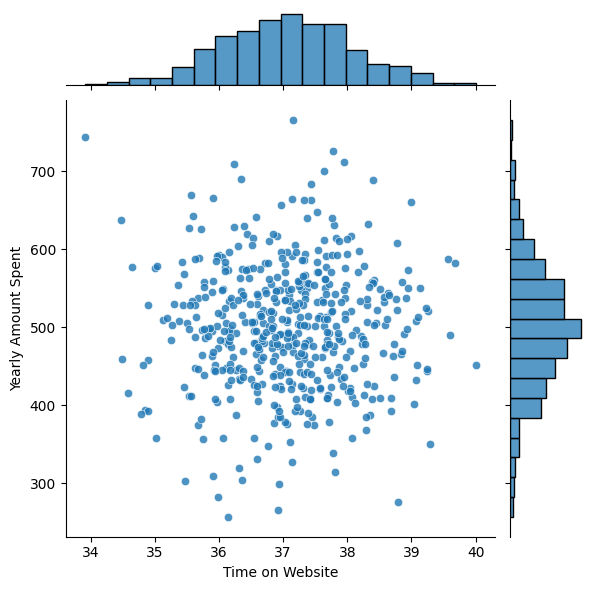

In [8]:
sns.jointplot(x="Time on Website",y="Yearly Amount Spent",data=df,alpha=0.8)# alpha is for overlapping dots
#realtionship btw the two variables

Avg. Session Length
Yearly Amount Spent


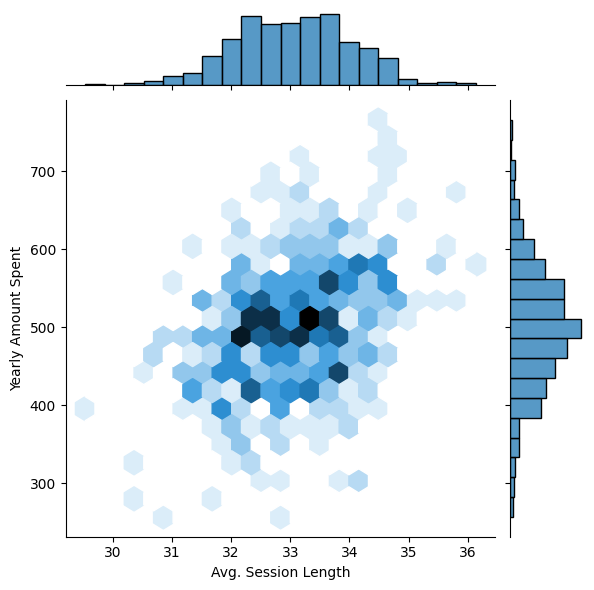

In [31]:
sns.jointplot(x=input(),y=input(),data=df,kind='hex')


In [32]:
df[['Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent']]

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,34.497268,12.655651,39.577668,4.082621,587.951054
1,31.926272,11.109461,37.268959,2.664034,392.204933
2,33.000915,11.330278,37.110597,4.104543,487.547505
3,34.305557,13.717514,36.721283,3.120179,581.852344
4,33.330673,12.795189,37.536653,4.446308,599.406092
...,...,...,...,...,...
495,33.237660,13.566160,36.417985,3.746573,573.847438
496,34.702529,11.695736,37.190268,3.576526,529.049004
497,32.646777,11.499409,38.332576,4.958264,551.620145
498,33.322501,12.391423,36.840086,2.336485,456.469510


In [33]:
df.columns=df.columns.str.strip()

In [34]:
selected_features=df[['Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent']]

In [35]:
#compute the correlation matrix
corr=selected_features.corr()
corr

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
Avg. Session Length,1.000000,-0.027826,-0.034987,0.060247,0.355088
Time on App,-0.027826,1.000000,0.082388,0.029143,0.499328
Time on Website,-0.034987,0.082388,1.000000,-0.047582,-0.002641
Length of Membership,0.060247,0.029143,-0.047582,1.000000,0.809084
Yearly Amount Spent,0.355088,0.499328,-0.002641,0.809084,1.000000


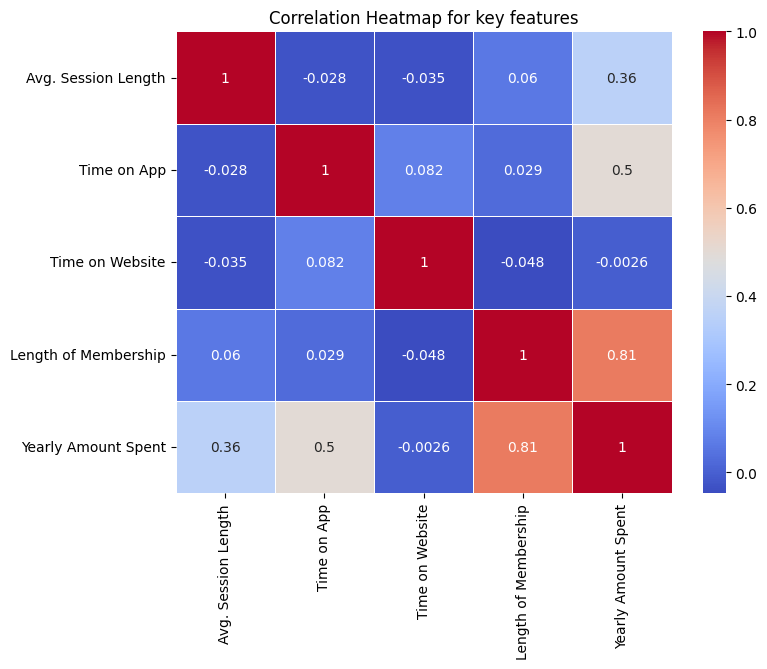

In [36]:
#set figure size
plt.figure(figsize=(8,6))
#create heatmap
sns.heatmap(corr,annot=True,cmap='coolwarm',linewidths=0.5)
plt.title("Correlation Heatmap for key features")
plt.show()

In [37]:
df.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

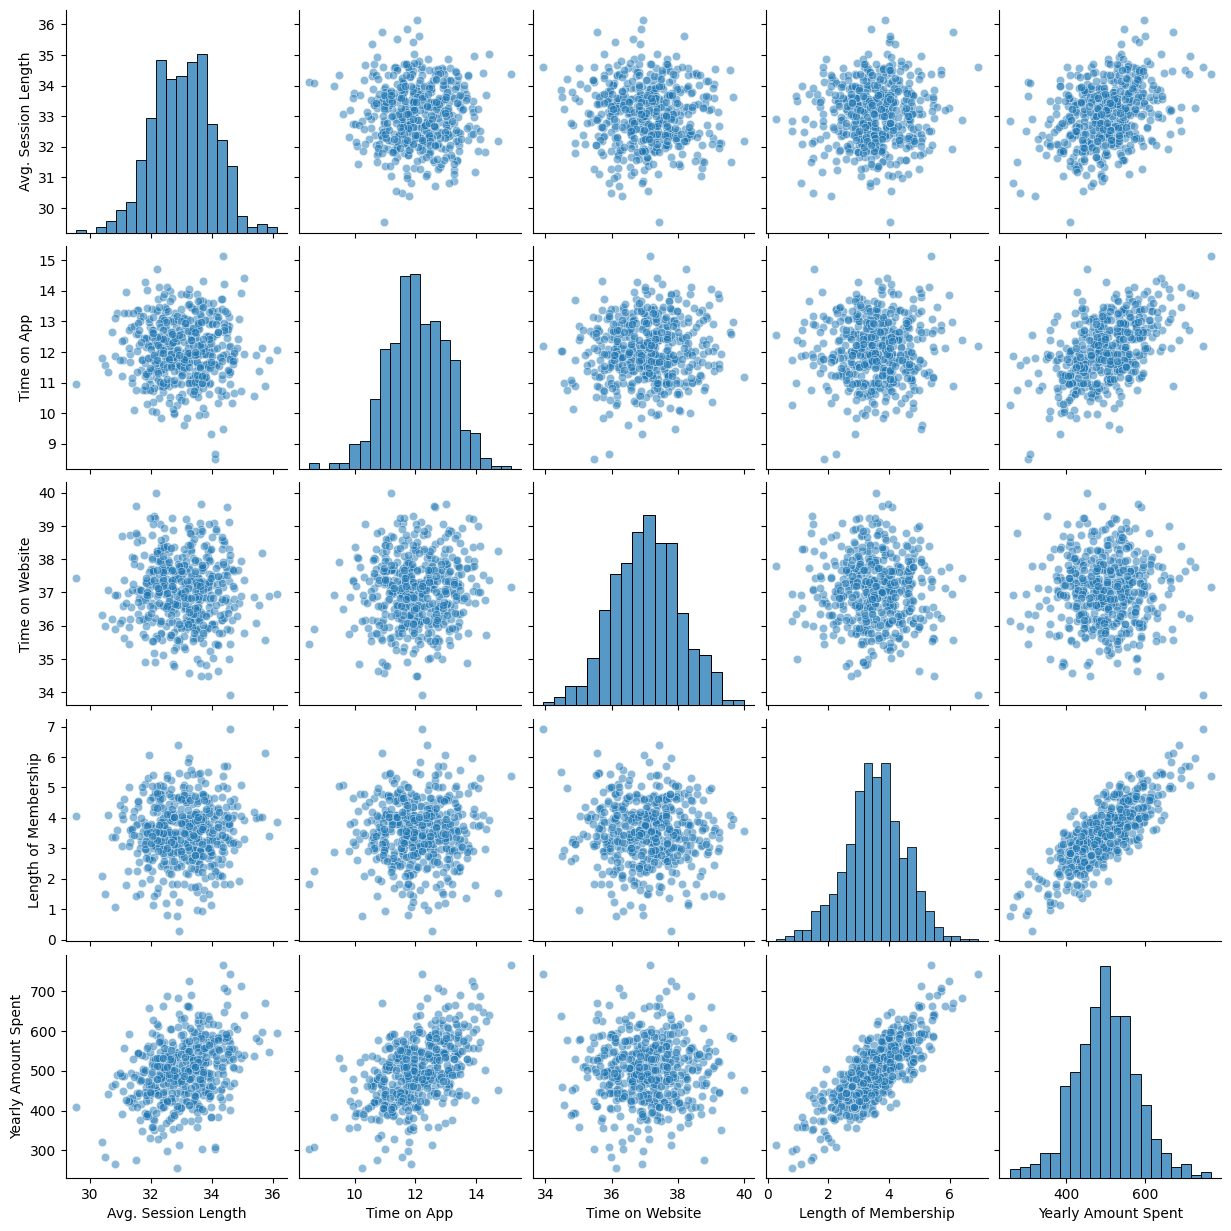

In [38]:
sns.pairplot(df,kind='scatter',plot_kws={'alpha':0.5})

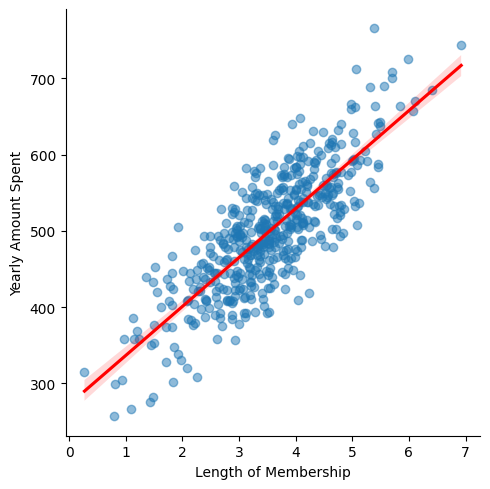

In [39]:
sns.lmplot(x='Length of Membership',
           y='Yearly Amount Spent',
           data=df,
           scatter_kws={'alpha':0.5},
           line_kws={'color':'red'},     #color for best fit line
           ci=95)      #confidence interval (default 95 %)

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
df.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

In [42]:
X=df[['Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership']]
y=df['Yearly Amount Spent']

In [43]:
X.shape

(500, 4)

In [44]:
y

,Yearly Amount Spent
0,587.951054
1,392.204933
2,487.547505
3,581.852344
4,599.406092
...,...
495,573.847438
496,529.049004
497,551.620145
498,456.469510


In [45]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [46]:
from sklearn.linear_model import LinearRegression

In [47]:
lm=LinearRegression()

In [48]:
lm.fit(X_train,y_train)

LinearRegression()

In [49]:
lm.coef_


array([25.72425621, 38.59713548,  0.45914788, 61.67473243])

In [50]:
cdf=pd.DataFrame(lm.coef_,X.columns,columns=['Coeff'])
print(cdf)

                          Coeff
Avg. Session Length   25.724256
Time on App           38.597135
Time on Website        0.459148
Length of Membership  61.674732


# PREDICTION

In [51]:
prediction=lm.predict(X_test)

In [52]:
X_test

,Avg. Session Length,Time on App,Time on Website,Length of Membership
361,32.077590,10.347877,39.045156,3.434560
73,32.808698,12.817113,37.031539,3.851579
374,31.447446,10.101632,38.043453,4.238296
155,32.449522,13.457725,37.238806,2.941411
104,31.389585,10.994224,38.074452,3.428860
...,...,...,...,...
266,34.555283,11.777772,37.979827,3.784273
23,32.903251,11.657576,36.772604,3.919302
222,34.334865,11.109456,38.585855,3.892891
261,32.550527,13.041245,36.655208,3.456234


In [53]:
y_test

,Yearly Amount Spent
361,401.033135
73,534.777188
374,418.602742
155,503.978379
104,410.069611
...,...
266,554.003093
23,519.340989
222,502.409785
261,514.009818


In [54]:
prediction

array([403.66993069, 542.57756289, 427.06591658, 502.02460425,
       410.12143559, 569.93442508, 531.93431341, 506.29650969,
       408.71870658, 473.97737105, 441.46912726, 425.33703059,
       425.1297229 , 527.61676714, 431.45684016, 424.0769184 ,
       575.76543296, 484.89856554, 458.35936863, 481.96502182,
       502.32441491, 513.63783554, 507.58877002, 646.57464283,
       450.24372141, 496.27043415, 556.40457807, 554.95630839,
       399.64237199, 325.84623136, 532.89783259, 478.12238702,
       501.05701845, 305.97335848, 505.77244448, 483.79591969,
       518.8331528 , 438.18241857, 456.71094234, 471.04609461,
       494.44008972, 445.31155755, 508.78802753, 501.04594193,
       488.83499673, 535.38079541, 595.20129802, 514.04714872,
       280.76758312, 433.10112367, 421.70823427, 481.23640152,
       584.71372272, 608.7748096 , 563.98513427, 494.72804869,
       394.52133407, 456.4197529 , 573.08767515, 499.6984241 ,
       512.83277025, 392.12434043, 480.05057697, 481.54

<Axes: xlabel='Yearly Amount Spent'>

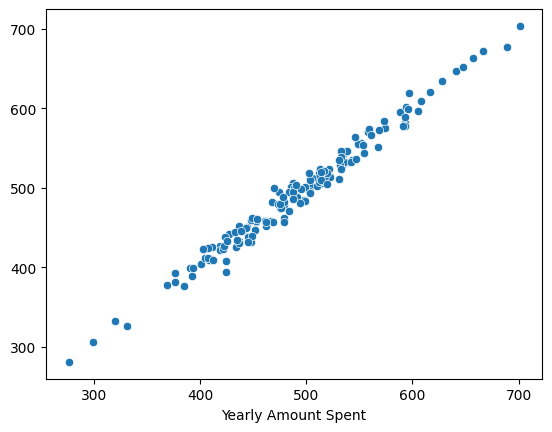

In [55]:
sns.scatterplot(x=y_test,y=prediction)

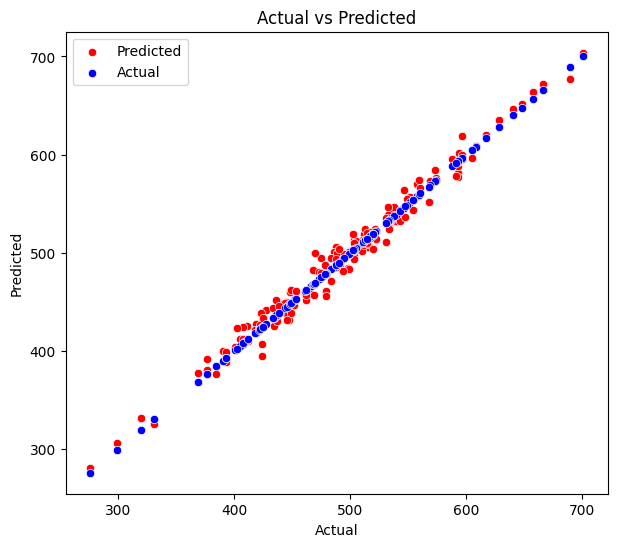

In [56]:
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test,y=prediction,color='red',label='Predicted')
sns.scatterplot(x=y_test,y=y_test,color='blue',label='Actual')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()


<Figure size 700x600 with 0 Axes>

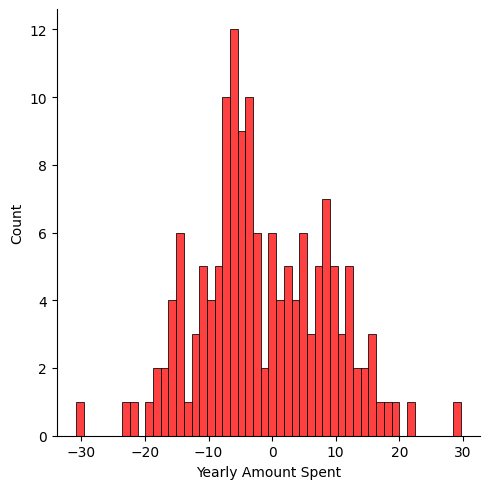

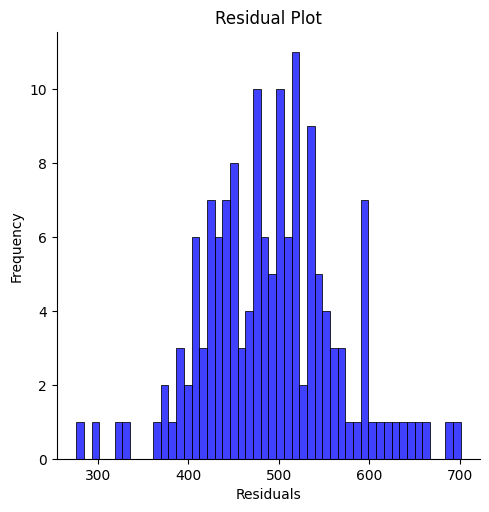

In [57]:
plt.figure(figsize=(7,6))
sns.displot(y_test-prediction,bins=50,color='red')
sns.displot(y_test,bins=50,color='blue')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residual Plot')
plt.show()


In [58]:
y_test.describe()

,Yearly Amount Spent
count,150.000000
mean,492.194085
std,73.960647
min,275.918421
25%,440.166540
50%,490.490638
75%,534.461625
max,700.917092


In [59]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

mae=mean_absolute_error(y_test,prediction)
mse=mean_squared_error(y_test,prediction)
rmse=np.sqrt(mse)
print('MAE:',mae)
print('MSE:',mse)
print('RMSE:',rmse)

MAE: 8.426091641432068
MSE: 103.9155413650325
RMSE: 10.193897260863114


In [60]:
from sklearn.model_selection import train_test_split


In [61]:
X=df[[ 'Time on App',
       'Time on Website', 'Length of Membership']]
y=df['Yearly Amount Spent']

In [62]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [63]:
from sklearn.linear_model import LinearRegression

In [64]:
lm=LinearRegression()

In [65]:
lm.fit(X_train,y_train)

LinearRegression()

In [66]:
lm.coef_


array([38.00802494,  0.53288794, 62.7706933 ])

In [67]:
cdf=pd.DataFrame(lm.coef_,X.columns,columns=['Coeff'])
print(cdf)

                          Coeff
Time on App           38.008025
Time on Website        0.532888
Length of Membership  62.770693


In [68]:
prediction=lm.predict(X_test)

In [69]:
X_test

,Time on App,Time on Website,Length of Membership
361,10.347877,39.045156,3.434560
73,12.817113,37.031539,3.851579
374,10.101632,38.043453,4.238296
155,13.457725,37.238806,2.941411
104,10.994224,38.074452,3.428860
...,...,...,...
347,11.304462,37.833972,5.137817
86,12.517666,37.151921,2.669942
75,12.238057,38.730862,3.120569
438,10.047315,37.181447,3.535088


In [70]:
y_test

,Yearly Amount Spent
361,401.033135
73,534.777188
374,418.602742
155,503.978379
104,410.069611
...,...
347,593.156401
86,487.379306
75,478.719357
438,392.992256


In [71]:
prediction

array([429.70311716, 548.65745084, 470.26114064, 515.98441255,
       453.39443143, 585.11743779, 480.51493209, 507.71747109,
       424.28380057, 476.29686338, 469.87261727, 414.17412232,
       428.49109436, 488.18274309, 447.76100846, 409.91693547,
       570.20898544, 479.20713535, 443.86053683, 483.9572349 ,
       459.8707049 , 480.42799177, 526.28486419, 631.15892174,
       436.72499559, 504.25442362, 568.73485713, 528.7733972 ,
       429.33586748, 352.46126987, 514.57541457, 497.45812383,
       497.21017615, 316.50895917, 508.06666791, 472.21988801,
       544.38846614, 434.49708582, 469.13801891, 477.8375517 ,
       480.7030579 , 425.01330981, 500.30180199, 514.25502994,
       495.81790017, 534.29393527, 558.38005869, 493.16351033,
       318.76740563, 470.06748055, 439.49602566, 494.40420525,
       601.82817987, 603.88739815, 602.11028759, 472.1731245 ,
       401.67379998, 474.88350947, 534.71133597, 513.08914159,
       501.46987116, 402.8150418 , 488.64788058, 466.42

<Axes: xlabel='Yearly Amount Spent'>

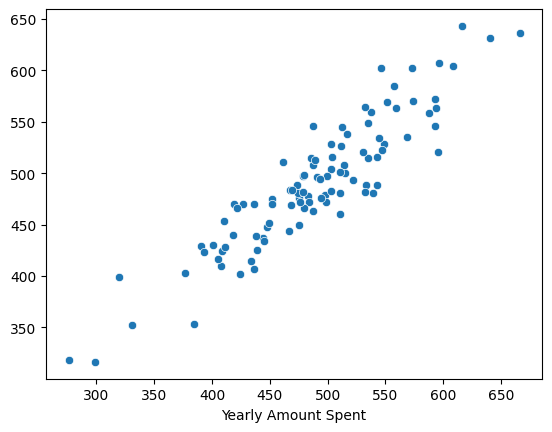

In [72]:
sns.scatterplot(x=y_test,y=prediction)

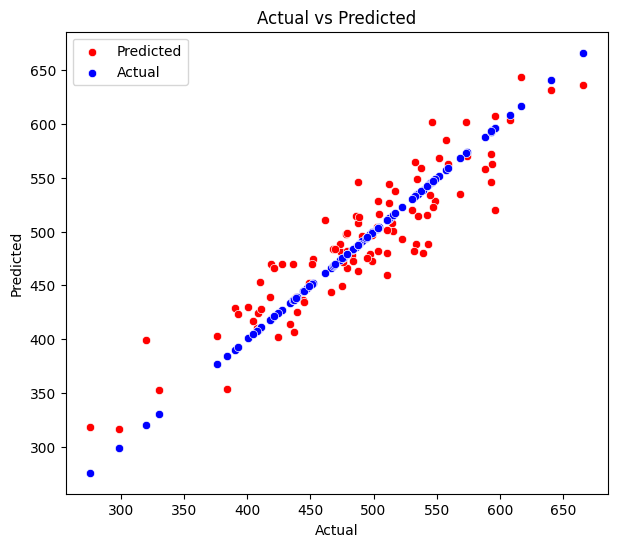

In [73]:
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test,y=prediction,color='red',label='Predicted')
sns.scatterplot(x=y_test,y=y_test,color='blue',label='Actual')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()


In [74]:
y_test.describe()

,Yearly Amount Spent
count,100.000000
mean,488.601586
std,70.723040
min,275.918421
25%,444.796391
50%,488.170760
75%,534.913294
max,666.125592


In [75]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

mae=mean_absolute_error(y_test,prediction)
mse=mean_squared_error(y_test,prediction)
rmse=np.sqrt(mse)
print('MAE:',mae)
print('MSE:',mse)
print('RMSE:',rmse)

MAE: 23.135922821258347
MSE: 807.1362660554383
RMSE: 28.410143717613227


In [82]:
#prediction on unseen data
unseen = pd.read_csv('Dataset.csv')

# Select only the features used for training
unseen_features = unseen[['Time on App', 'Time on Website', 'Length of Membership']]

# Make predictions
prediction = lm.predict(unseen_features)

# Save results
pd.DataFrame(prediction, columns=['Predicted']).to_csv('predicted_output.csv', index=False)
print("✅ Predictions saved as predicted_output.csv")

✅ Predictions saved as predicted_output.csv


# Conclusion: What Really Matters to Our Customers 🌟

Our analysis revealed surprising insights about what drives customer spending! 📊💸

## Key Findings 🔍

- **Membership is King** 👑: The duration of a customer's membership is the most critical factor in predicting their spending. It outweighs time spent on the app or website today.
- **The App Dominates** 📱: The mobile app has a significantly stronger influence on customer spending compared to the desktop website.
- **Desktop Time is Meaningless** 💻❌: Time spent on the desktop website has little to no correlation with how much customers spend.

## What This Means 🚀

We can interpret these findings in two key ways:

1. **Fix the Website** 🛠️: The desktop website may require major improvements to convert visitors into buyers.
2. **Focus on the App** 📲: The mobile app clearly drives more spending. We should prioritize marketing and development efforts to leverage the app’s strengths and encourage its use.

> In summary, while a comprehensive marketing strategy requires expert input, our model highlights the customer actions and characteristics most critical for generating revenue! 💰